## Deutsch - Jozsa Algorithm 

This notebook implements the Deutsch-Jozsa algorithm, a quantum algorithm that checks whether a function $f$ that takes an $m$-bit input is balanced or constant, using $m+1$ qubits. This is a generalization of the Deutsch algorithm that takes a one bit input to $f$. Historically, the Deutsch algorithm is the first algorithm that demonstrates a deterministic (quantum) query complexity advantage over its classical counterpart. 

### Let us now consider the Deutsch - Jozsa algorithm ($m$ bit input)
We have the function $f$ given as a black box (we do not know the exact function definition, but we are able to evaluate it, such that given an input $x$ we can retrieve $f(x)$ and this function is either **constant** or **balanced**), that takes as an input an $m$-bit sequence and returns a binary output:
$$
    f: \{ 0,1\}^m \rightarrow \{ 0,1\}.
$$

With regard to query complexity, the quantum algorithm needs only one evaluation to check if the function $f$ is balanced or constant, whereas a classical algorithm has the worst case query complexity of $2^{m-1} +1 $ (note that for a binary $m$-bit string we have $2^m$ possible input strings), which is an exponential advantage. 

## Reference:
Nielsen, Michael A., and Isaac L. Chuang. Quantum computation and quantum information. Cambridge university press, 2010.

In [1]:
%%capture
!pip install qiskit --upgrade 
!pip install matplotlib
!pip install qiskit-aer

import matplotlib
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

## 1. Define the Oracle implementation for our constant (0 or 1 as example) and balanced function

We prepare the quantum circuits in order to fulfill the (reversible) transformation: $| x \rangle | y \rangle \rightarrow | x \rangle | f(x) \oplus y \rangle$ for a constant or balanced function $f$ with $x$ being the $m$-bit input and the output being added to the $(m+1)th$ qubit.

In [2]:
def constant_0_oracle(m):
    """Create a constant 0 oracle."""
    qc = QuantumCircuit(m+1)
    return qc

def constant_1_oracle(m):
    """Create a constant 1 oracle."""
    qc = QuantumCircuit(m+1)
    qc.x(m)
    return qc

def balanced_oracle(m):
    """Create a balanced oracle."""
    qc = QuantumCircuit(m+1)
    # variation: apply pair of X gates 
    #for i in range(m // 2): 
    #    qc.x(i)
    # Apply Z gate to the first half of the qubits
    for i in range(m):
        qc.cx(i, m)
    #for i in range(m // 2):
    #    qc.x(i)
    return qc

In [3]:
# let's visualize the quantum circuit for the balanced oracle
qc = balanced_oracle(m=4)
qc.draw()

q_0: ──■─────────────────
       │                 
q_1: ──┼────■────────────
       │    │            
q_2: ──┼────┼────■───────
       │    │    │       
q_3: ──┼────┼────┼────■──
     ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐
q_4: ┤ X ├┤ X ├┤ X ├┤ X ├
     └───┘└───┘└───┘└───┘

**Variation**: Test out the different oracles (balanced or constant) and see how the output changes. Can you implent an alternative oracle that is constant or balanced?

In [4]:
# Define the Parameters and function type (balanced or constant)
m = 4 # number of bits of the function f -> 2^m possible inputs -> (m+1) qubits needed
oracle = constant_1_oracle # choose oracle type: constant_0_oracle, constant_1_oracle or balanced_oracle

## 2. Prepare the Quantum Circuit for the Deutsch-Jozsa algorithm

First, we prepare the initial state $ |0\rangle^{m} |1 \rangle$ and then apply Hadamard gates $H^{(m+1)}$, following that, the respective oracle is applied and next, we apply $H^{m} \otimes \mathbb{I}$. Then we measure the first $m$ qubits and conclude whether the function implemented via the oracle was **balanced** or **constant** by evaluating the measurement outcome. 

In [5]:
# define the quantum circuit of the Deutsch Jozsa algorithm
qc = QuantumCircuit(m + 1, m)
# initialize the last qubit in state |1> and first m qubits in state |0>
qc.x(m)  # Set the last qubit to |1>
qc.barrier()
# apply Hadamard gates to the first m qubits
for i in range(m):
    qc.h(i)
qc.h(m)  # apply Hadamard gate to the last qubit
qc.barrier()
# apply the oracle
qc_oracle = oracle(m)
qc_oracle.to_gate(label=' Oracle')
qc.append(qc_oracle, range(m+1))
qc.barrier()
# apply Hadamard gates to the first m qubits again
for i in range(m):
    qc.h(i)
qc.barrier()
# measure the first m qubits
qc.measure(range(m), range(m))
# visualize the circuit
qc.draw()


░ ┌───┐ ░ ┌─────────────┐ ░ ┌───┐ ░ ┌─┐         
q_0: ──────░─┤ H ├─░─┤0            ├─░─┤ H ├─░─┤M├─────────
           ░ ├───┤ ░ │             │ ░ ├───┤ ░ └╥┘┌─┐      
q_1: ──────░─┤ H ├─░─┤1            ├─░─┤ H ├─░──╫─┤M├──────
           ░ ├───┤ ░ │             │ ░ ├───┤ ░  ║ └╥┘┌─┐   
q_2: ──────░─┤ H ├─░─┤2 circuit-48 ├─░─┤ H ├─░──╫──╫─┤M├───
           ░ ├───┤ ░ │             │ ░ ├───┤ ░  ║  ║ └╥┘┌─┐
q_3: ──────░─┤ H ├─░─┤3            ├─░─┤ H ├─░──╫──╫──╫─┤M├
     ┌───┐ ░ ├───┤ ░ │             │ ░ └───┘ ░  ║  ║  ║ └╥┘
q_4: ┤ X ├─░─┤ H ├─░─┤4            ├─░───────░──╫──╫──╫──╫─
     └───┘ ░ └───┘ ░ └─────────────┘ ░       ░  ║  ║  ║  ║ 
c: 4/═══════════════════════════════════════════╩══╩══╩══╩═
                                                0  1  2  3

## 3. Simulate the quantum circuit and evaluate the simulation results

We now run the circuit on a simulator and inspect the measurement outcomes
on the first $m$ qubits. The decision rule established above tells us:

- if the measured bitstring is $0^m = \underbrace{00\ldots 0}_{m}$, then $f$ is **constant**;
- if any other bitstring is measured, then $f$ is **balanced**.

In a noiseless simulation, all the probability is concentrated to a single outcome, so a single shot suffices to decide. On real hardware, due to noise, many shots are required and one can then look at the histogram to make the distinction. 

In [6]:
# define number of shots and backend for simulation 
no_shots =  1e5
backend = AerSimulator()
t_qc = transpile(qc, backend)
result = backend.run(t_qc, shots=no_shots).result()
counts = result.get_counts()


Visualize the simulation results:

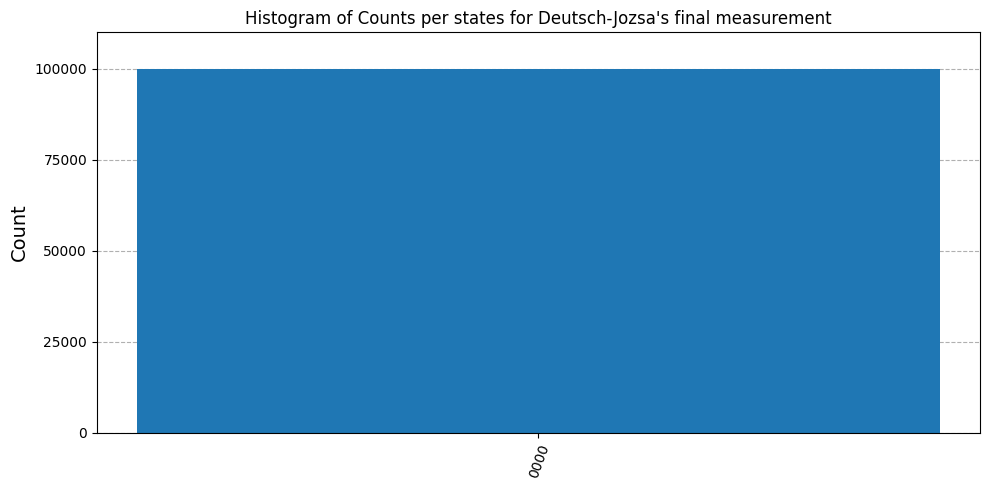

In [7]:
# visualize the counts: if one measures an all-zero string a constant function is implemented and for other results one has a balanced function
plot_histogram(counts, title='Histogram of Counts per states for Deutsch-Jozsa\'s final measurement', figsize=(10, 5), bar_labels=False)